# 02 — Exploratory Analysis

This notebook explores the pulsar photon dataset before signal preprocessing and period detection.

## Objectives

- inspect photon arrival-time distribution;
- explore energy-related features;
- visualize basic signal properties;
- identify patterns or anomalies before preprocessing.



In [1]:
import warnings

import psrqpy
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=RuntimeWarning)

query = psrqpy.QueryATNF()
df = query.table.to_pandas()

df.shape


(4351, 511)

In [2]:
selected_columns = [
    "PSRJ",
    "P0",
    "P1",
    "DM",
    "DIST",
    "AGE",
    "EDOT",
    "BINARY",
]

available_columns = [col for col in selected_columns if col in df.columns]
df_selected = df[available_columns].copy()

df_selected.head()

,PSRJ,P0,P1,DM,DIST,AGE,EDOT,BINARY
0,J0002+6216,0.115364,5.967033e-15,218.6,6.357,3.063207e+05,1.534306e+35,NaN
1,J0006+1834,0.693748,2.097000e-15,11.4,0.860,5.241664e+06,2.479440e+32,NaN
2,J0007+7303,0.315873,3.603905e-13,NaN,1.400,1.388691e+04,4.514345e+35,NaN
3,J0011+08,2.552870,NaN,24.9,5.399,NaN,NaN,NaN
4,J0012+5431,3.025301,1.281342e-16,131.3,5.427,3.740843e+08,1.826919e+29,NaN


In [3]:
df.columns


Index(['PSRJ', 'PSRJ_REF', 'RAJ', 'RAJ_ERR', 'RAJ_REF', 'DECJ', 'DECJ_ERR',
       'DECJ_REF', 'POSEPOCH', 'POSEPOCH_REF',
       ...
       'UPRMASS', 'MASSFN_ERR', 'MINOMDOT', 'H0_SD', 'ASSOC_ORIG', 'ASSOC_REF',
       'TYPE_ORIG', 'TYPE_REF', 'BINCOMP_ORIG', 'BINCOMP_REF'],
      dtype='str', length=511)

In [4]:
stable_pulsars = df[['PSRJ', 'P0', 'P1', 'DIST']].dropna()
stable_pulsars.sort_values('P1').head(10)


,PSRJ,P0,P1,DIST
720,J1130+0921,4.796637,-2.760927e-15,3.386
747,J1144-6146,0.987783,-3.805290e-17,1.395
4169,J2129+1210A,0.110665,-2.099066e-17,10.710
2465,J1829-1011,0.829166,-5.000000e-18,4.938
2143,J1801-0857F,0.024892,-2.670833e-18,9.200
2303,J1817-0743,0.438095,-2.303130e-18,0.195
4172,J2129+1210D,0.004803,-1.070097e-18,10.710
2142,J1801-0857E,0.007602,-1.035977e-18,9.200
2051,J1750-3703C,0.026569,-9.960174e-19,12.730
3350,J1910-5959B,0.008358,-7.904100e-19,4.120


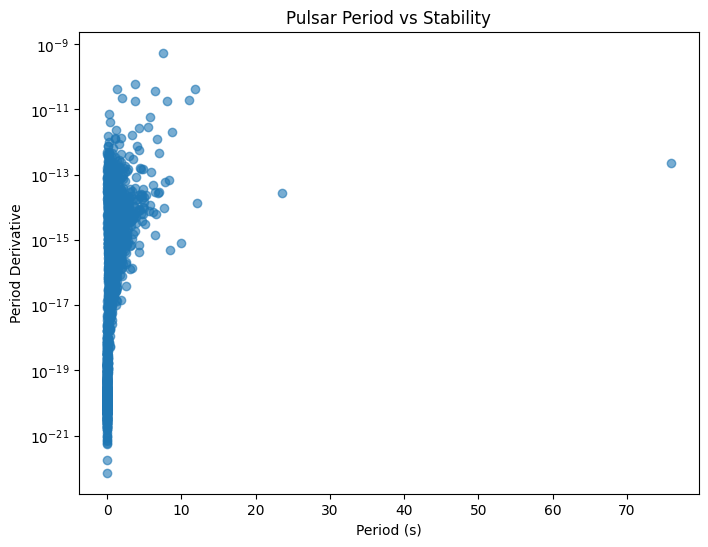

In [5]:
plt.figure(figsize=(8,6))
plt.scatter(stable_pulsars['P0'], stable_pulsars['P1'], alpha=0.6)
plt.xlabel('Period (s)')
plt.ylabel('Period Derivative')
plt.yscale('log')
plt.title('Pulsar Period vs Stability')
plt.show()


## Insights

- Pulsars with shorter periods tend to have lower period derivatives,
  indicating higher timing stability.
- Millisecond pulsars appear as promising candidates for use
  as natural navigation beacons.
- Timing stability is a more critical factor than distance alone.


In [6]:
df[['P0', 'P1']].isna().sum()


P0      65
P1    1477
dtype: int64

In [7]:
clean_df = df[
    (df['P1'].notna()) &
    (df['P1'] > 0) &
    (df['P0'].notna())
]



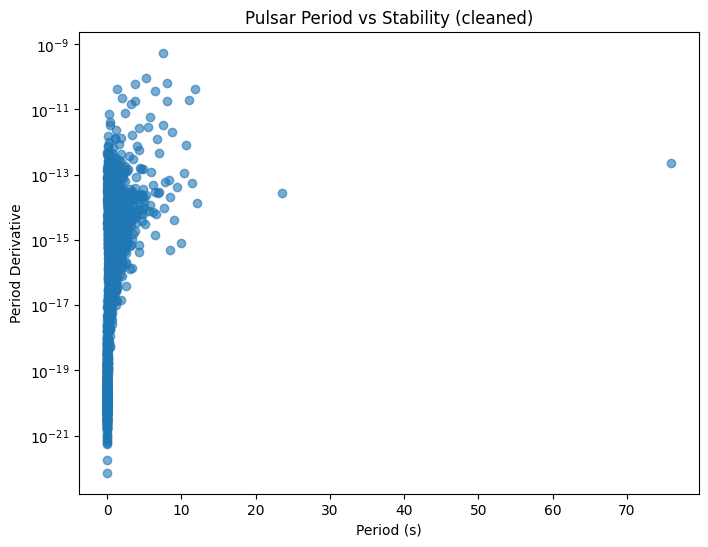

In [8]:
plt.figure(figsize=(8,6))
plt.scatter(clean_df['P0'], clean_df['P1'], alpha=0.6)
plt.yscale('log')
plt.xlabel('Period (s)')
plt.ylabel('Period Derivative')
plt.title('Pulsar Period vs Stability (cleaned)')
plt.show()


## Data Quality Notes

- The ATNF catalogue contains missing and zero values for some timing parameters.
- Rows with undefined or zero period derivatives were excluded from stability analysis.
- This preprocessing step is necessary to avoid invalid mathematical operations.


In [9]:
from astropy.io import fits

hdul = fits.open("../data/raw/vela_photons.fits")
hdul.info()


Filename: ../data/raw/vela_photons.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      31   ()      
  1  EVENTS        1 BinTableHDU    208   540091R x 23C   [E, E, E, E, E, E, E, E, E, D, J, J, I, 3I, 32X, 32X, I, D, E, E, E, E, E]   
  2  GTI           1 BinTableHDU     46   1653R x 2C   [D, D]   


In [10]:
from pathlib import Path

import numpy as np
import pandas as pd
from astropy.io import fits

data_path = Path("../data/raw/vela_photons.fits")

if not data_path.exists():
    raise FileNotFoundError(
        f"Data file not found: {data_path}\n"
        "Please place vela_photons.fits into data/raw/ before running this notebook."
    )

with fits.open(data_path) as hdul:
    events = hdul[1].data

df = pd.DataFrame({
    "time": np.array(events["TIME"], dtype=np.float64),
    "energy": np.array(events["ENERGY"], dtype=np.float64),
})

df.describe()

,time,energy
count,5.400910e+05,540091.000000
mean,7.854256e+08,657.005789
std,2.455940e+06,2017.113152
min,7.804545e+08,100.000038
25%,7.830112e+08,186.619041
50%,7.861667e+08,320.299591
75%,7.874730e+08,634.793060
max,7.901001e+08,278458.968750


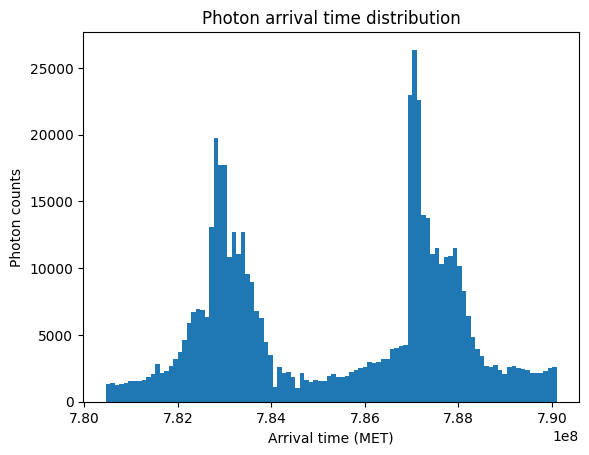

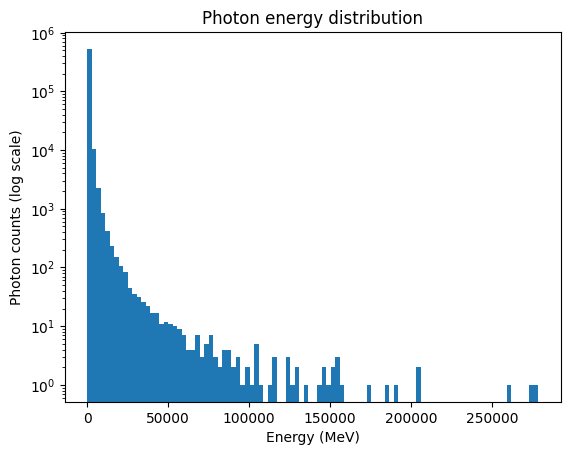

In [11]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df["time"], bins=100)
plt.xlabel("Arrival time (MET)")
plt.ylabel("Photon counts")
plt.title("Photon arrival time distribution")
plt.show()

plt.figure()
plt.hist(df["energy"], bins=100, log=True)
plt.xlabel("Energy (MeV)")
plt.ylabel("Photon counts (log scale)")
plt.title("Photon energy distribution")
plt.show()


In [12]:
print(df.dtypes)
df.describe()


time      float64
energy    float64
dtype: object


,time,energy
count,5.400910e+05,540091.000000
mean,7.854256e+08,657.005789
std,2.455940e+06,2017.113152
min,7.804545e+08,100.000038
25%,7.830112e+08,186.619041
50%,7.861667e+08,320.299591
75%,7.874730e+08,634.793060
max,7.901001e+08,278458.968750


In [13]:
df = pd.DataFrame({
    "time": events["TIME"].astype('float64'),
    "energy": events["ENERGY"].astype('float64')
})

print(df.dtypes)

print(df.describe())


time      float64
energy    float64
dtype: object
               time         energy
count  5.400910e+05  540091.000000
mean   7.854256e+08     657.005789
std    2.455940e+06    2017.113152
min    7.804545e+08     100.000038
25%    7.830112e+08     186.619041
50%    7.861667e+08     320.299591
75%    7.874730e+08     634.793060
max    7.901001e+08  278458.968750


In [14]:
df_filtered = df[df["energy"] > 100]

print(f"Filtered events: {len(df_filtered)}")


Filtered events: 540091


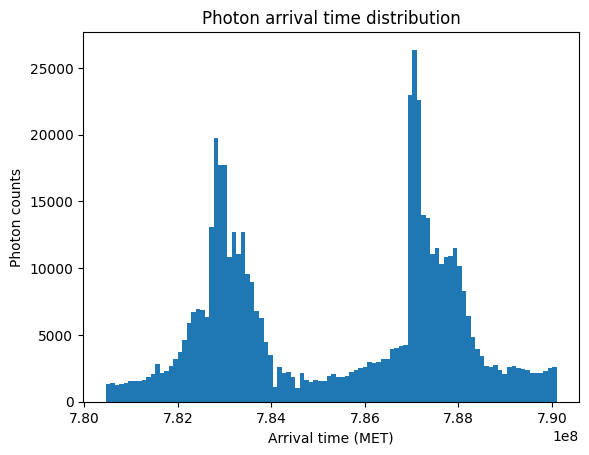

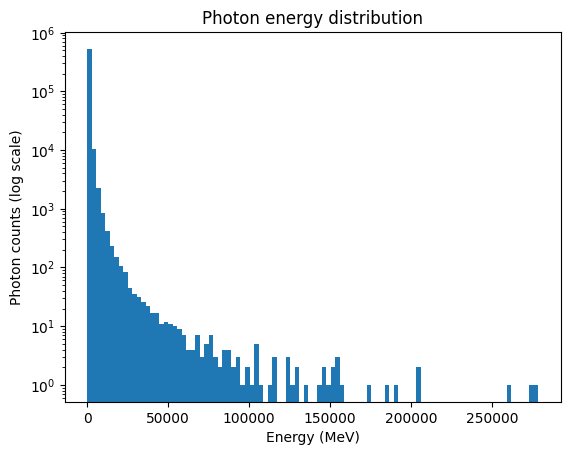

In [15]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df["time"], bins=100)
plt.xlabel("Arrival time (MET)")
plt.ylabel("Photon counts")
plt.title("Photon arrival time distribution")
plt.show()

plt.figure()
plt.hist(df["energy"], bins=100, log=True)
plt.xlabel("Energy (MeV)")
plt.ylabel("Photon counts (log scale)")
plt.title("Photon energy distribution")
plt.show()


The dataset contains more than 500,000 photon events detected by the Fermi LAT in the region of the Vela pulsar.
Photon arrival times span multiple years, and the energy distribution shows a strong concentration at lower energies, consistent with background-dominated gamma-ray observations.

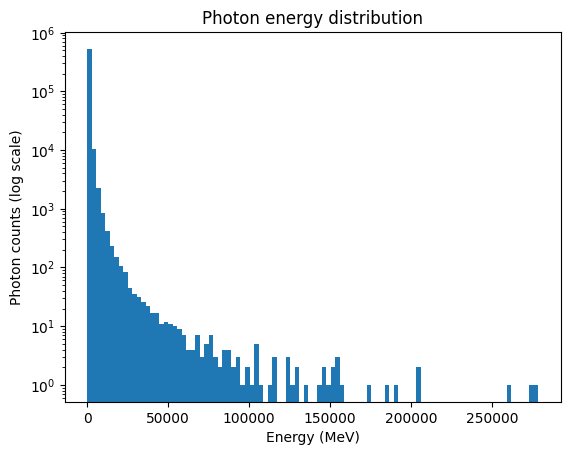

In [16]:
plt.figure()
plt.hist(df_filtered["energy"], bins=100, log=True)
plt.xlabel("Energy (MeV)")
plt.ylabel("Photon counts (log scale)")
plt.title("Photon energy distribution")
plt.show()


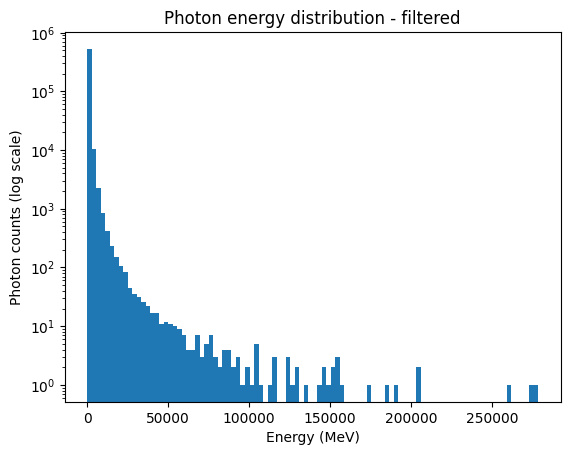

In [17]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df_filtered["energy"], bins=100, log=True)
plt.xlabel("Energy (MeV)")
plt.ylabel("Photon counts (log scale)")
plt.title("Photon energy distribution - filtered")
plt.show()


In [18]:
print(df_filtered["energy"].min(), df_filtered["energy"].max())
print(df_filtered["energy"].mean())


100.00003814697266 278458.96875
657.0057890879222


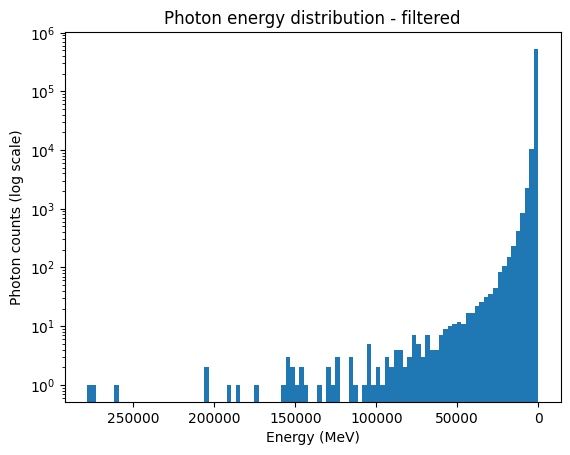

In [19]:
plt.figure()
plt.hist(df_filtered["energy"], bins=100, log=True)
plt.xlabel("Energy (MeV)")
plt.ylabel("Photon counts (log scale)")
plt.title("Photon energy distribution - filtered")
plt.gca().invert_xaxis() 
plt.show()


In [20]:
plt.savefig('../images/folded_profile_50bins.png', dpi=150)


FileNotFoundError: [Errno 2] No such file or directory: '../images/folded_profile_50bins.png'

<Figure size 640x480 with 0 Axes>

In [ ]:
import os
import matplotlib.pyplot as plt

images_dir = 'images'
os.makedirs(images_dir, exist_ok=True)

figures = [plt.figure(n) for n in plt.get_fignums()]

02_preprocessing

for i, fig in enumerate(figures, start=1):
    filename = f"{notebook_name}_fig{i}.png"
    filepath = os.path.join(images_dir, filename)
    fig.savefig(filepath, dpi=150, bbox_inches='tight')
    print(f"Saved: {filepath}")

plt.close('all')


In [ ]:
import os
import matplotlib.pyplot as plt

images_dir = 'images'
os.makedirs(images_dir, exist_ok=True)

figures = [plt.figure(n) for n in plt.get_fignums()]

notebook_name = '02_exploratory_analysis'

for i, fig in enumerate(figures, start=1):
    filename = f"{notebook_name}_fig{i}.png"
    filepath = os.path.join(images_dir, filename)
    fig.savefig(filepath, dpi=150, bbox_inches='tight')
    print(f"Saved: {filepath}")

plt.close('all')


## Conclusion

The exploratory analysis helped identify the main properties of the photon event data.  
The dataset is ready for preprocessing and period-search analysis.